# Project  — Bike Rental Demand Prediction

## Problem Understanding

Bike-sharing services need to predict the number of bikes that customers will rent at different times.

The goal of this project is to **predict bike rental demand** using factors such as weather conditions, season, temperature, humidity, and time-related features.

Accurate demand prediction can help a bike-sharing company:

- Keep enough bikes available when demand is high.
- Avoid having too many unused bikes when demand is low.
- Improve bike distribution and fleet management.
- Plan operations based on expected customer demand.
- Provide better service to customers.

## Prediction Goal

This is a **regression problem** because the target variable represents the number of bike rentals, which is a continuous numerical value.

**Target:** Bike rental count/demand.

### Dataset Collection & Exploration:

In [1]:
import pandas as pd
df = pd.read_csv("day.csv")
# First Five Rows:
df.head()
# Shape of the dataframe:
Shape = df.shape
print(Shape)
# Columns:
col_names = df.columns
print(col_names)
# Data Types:
data_type =df.dtypes
print(data_type)
# Statistical summary:
summary = df.describe()
print(summary)


(730, 16)
Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object
          instant      season          yr        mnth     holiday     weekday  \
count  730.000000  730.000000  730.000000  730.000000  730.000000  730.000000   
mean   365.500000    2.498630    0.500000    6.526027    0.028767    2.997260   
std    210.877136    1.110184    0.500343    3.450215    0.167266    2.006161   
min      1.000000    1.000000    0.000000    1.000000    0.000000    0.000000   
25%    183.2

### Data Cleaning & Preprocessing:

In [2]:
# Missing Value Analysis:
missing_val = df.isnull().sum()
print(missing_val)

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


>no missing values

## Duplicates:

In [3]:
duplicates =df.duplicated().sum()
print(duplicates)

0


## Encoding using Scikit Learn

In [4]:
from sklearn.preprocessing import OneHotEncoder

## Seperate Features & Target:

In [6]:
X = df.drop("cnt", axis=1)
y = df["cnt"]

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "season",
    "mnth",
    "weekday",
    "weathersit"
]

numerical_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [12]:
X_processed = preprocessor.fit_transform(X)

In [19]:
X_processed = preprocessor.fit_transform(X)

print("Processed shape:", X_processed.shape)
print("Encoded features:")
print(preprocessor.get_feature_names_out())

Processed shape: (730, 30)
Encoded features:
['num__temp' 'num__atemp' 'num__hum' 'num__windspeed' 'cat__season_1'
 'cat__season_2' 'cat__season_3' 'cat__season_4' 'cat__mnth_1'
 'cat__mnth_2' 'cat__mnth_3' 'cat__mnth_4' 'cat__mnth_5' 'cat__mnth_6'
 'cat__mnth_7' 'cat__mnth_8' 'cat__mnth_9' 'cat__mnth_10' 'cat__mnth_11'
 'cat__mnth_12' 'cat__weekday_0' 'cat__weekday_1' 'cat__weekday_2'
 'cat__weekday_3' 'cat__weekday_4' 'cat__weekday_5' 'cat__weekday_6'
 'cat__weathersit_1' 'cat__weathersit_2' 'cat__weathersit_3']


In [23]:
X_processed = preprocessor.fit_transform(X)

print(X_processed.shape)

(730, 30)


#### Final Dataset:

In [27]:
df_final = pd.DataFrame(X_processed)
df_final.head()
# Coverting the sparsed matrix into df
df_final = pd.DataFrame(
    X_processed.toarray()
)

df_final.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,-0.827613,-0.680818,1.252343,-0.387833,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.722069,-0.741507,0.480996,0.748899,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.635432,-1.750344,-1.338073,0.745931,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-1.615560,-1.610886,-0.261577,-0.389769,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.468226,-1.505615,-1.340294,-0.046477,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


### Exploratory Data Analysis:

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
df_final.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,-0.827613,-0.680818,1.252343,-0.387833,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.722069,-0.741507,0.480996,0.748899,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.635432,-1.750344,-1.338073,0.745931,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,-1.615560,-1.610886,-0.261577,-0.389769,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.468226,-1.505615,-1.340294,-0.046477,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


## Rental demand:

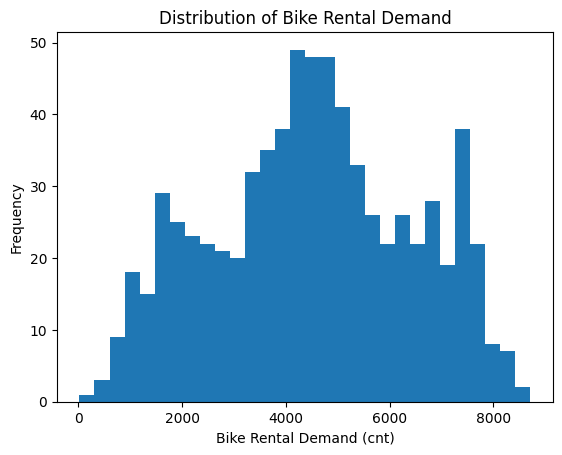

In [30]:
plt.hist(df["cnt"], bins=30)
plt.xlabel("Bike Rental Demand (cnt)")
plt.ylabel("Frequency")
plt.title("Distribution of Bike Rental Demand")
plt.show()

## Weather:

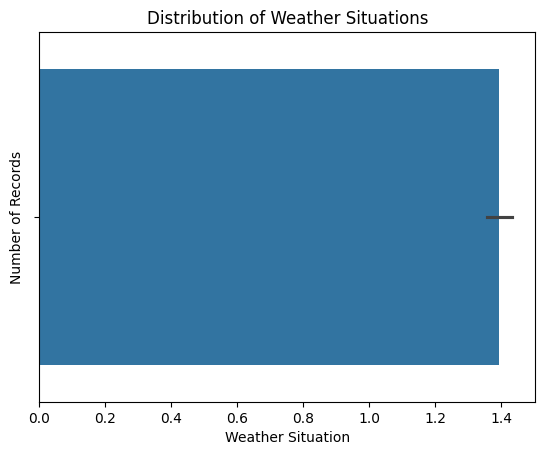

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="weathersit", data=df)

plt.xlabel("Weather Situation")
plt.ylabel("Number of Records")
plt.title("Distribution of Weather Situations")
plt.show()

### Weather vs Rental demand:

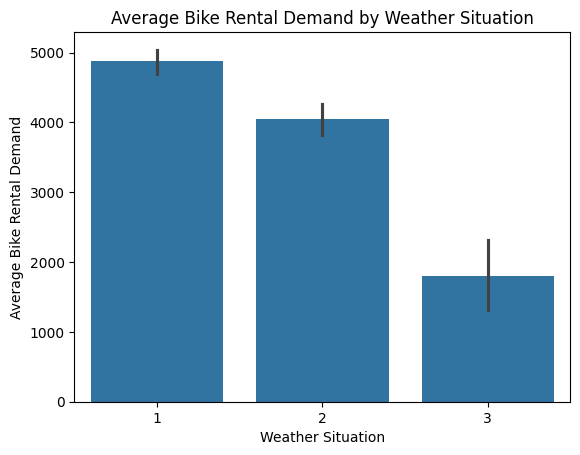

In [37]:
sns.barplot(x="weathersit", y="cnt", data=df)

plt.xlabel("Weather Situation")
plt.ylabel("Average Bike Rental Demand")
plt.title("Average Bike Rental Demand by Weather Situation")
plt.show()

## Time based Analysis:

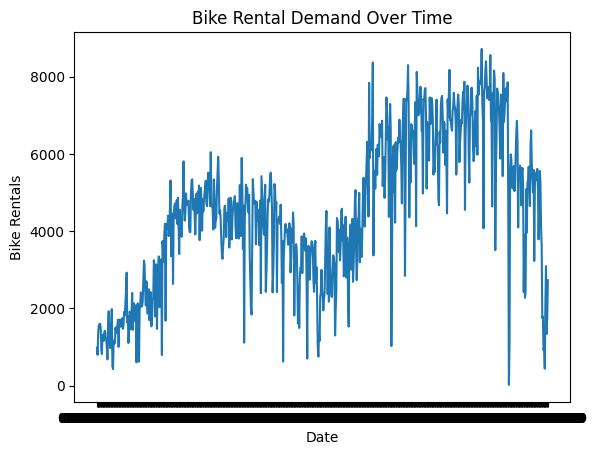

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x="dteday", y="cnt", data=df)

plt.xlabel("Date")
plt.ylabel("Bike Rentals")
plt.title("Bike Rental Demand Over Time")

plt.show()

## Plotly plots:

#### Demand Over Time:

In [38]:
import plotly.express as px

fig = px.line(
    df,
    x="dteday",
    y="cnt",
    title="🚲 Bike Rental Demand Over Time",
    hover_data=["temp", "hum", "windspeed", "weathersit"]
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Date",
    yaxis_title="Rental Demand",
    hovermode="x unified"
)

fig.show()

### Weather → Demand:

In [39]:
fig = px.box(
    df,
    x="weathersit",
    y="cnt",
    points="outliers",
    title="🌤️ Bike Rental Demand Across Weather Conditions",
    labels={
        "weathersit": "Weather Situation",
        "cnt": "Rental Demand"
    }
)

fig.update_layout(template="plotly_white")

fig.show()

## Temperature vs demand:

In [42]:
fig = px.scatter(
    df,
    x="temp",
    y="cnt",
    color="weathersit",
    size="cnt",
    hover_data=["dteday", "hum", "windspeed"],
    title="🌡️ Temperature vs Bike Rental Demand"
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Temperature",
    yaxis_title="Rental Demand"
)

fig.show()

# Interactive plot:

In [44]:
df["dteday"] = pd.to_datetime(df["dteday"], dayfirst=True)

df["year"] = df["dteday"].dt.year
df["month"] = df["dteday"].dt.month

In [45]:
df["year_month"] = df["dteday"].dt.to_period("M").astype(str)

In [46]:
df[["dteday", "year", "month", "year_month"]].head()

,dteday,year,month,year_month
0,2018-01-01,2018,1,2018-01
1,2018-01-02,2018,1,2018-01
2,2018-01-03,2018,1,2018-01
3,2018-01-04,2018,1,2018-01
4,2018-01-05,2018,1,2018-01


In [48]:
import plotly.express as px

fig = px.scatter(
    df,
    x="temp",
    y="cnt",
    animation_frame="year_month",
    animation_group="dteday",
    color="weathersit",
    size="cnt",
    hover_data=[
        "dteday",
        "temp",
        "hum",
        "windspeed",
        "cnt"
    ],
    title="🚲 Bike Rental Demand: Weather & Temperature Over Time",
    labels={
        "temp": "Temperature",
        "cnt": "Rental Demand",
        "weathersit": "Weather",
        "year_month": "Month"
    },
    size_max=45
)

fig.update_layout(
    template="plotly_white",
    xaxis_title="Temperature",
    yaxis_title="Bike Rental Demand",
    hovermode="closest"
)

fig.show()

In [49]:
import pandas as pd
import plotly.express as px

# Convert date
df["dteday"] = pd.to_datetime(df["dteday"], dayfirst=True)

# Create month and year
df["year"] = df["dteday"].dt.year
df["month"] = df["dteday"].dt.month

# Average rental demand for each year-month
monthly = (
    df.groupby(["year", "month"], as_index=False)["cnt"]
      .mean()
)

# Create readable animation label
monthly["period"] = (
    monthly["year"].astype(str)
    + "-"
    + monthly["month"].astype(str).str.zfill(2)
)

fig = px.bar(
    monthly,
    x="month",
    y="cnt",
    animation_frame="period",
    animation_group="month",
    range_y=[0, monthly["cnt"].max() * 1.15],
    title="🚲 Bike Rental Demand Through the Year",
    labels={
        "month": "Month",
        "cnt": "Average Rental Demand"
    },
    text_auto=".0f"
)

fig.update_layout(
    template="plotly_dark",
    xaxis=dict(
        tickmode="linear",
        dtick=1
    ),
    yaxis_title="Average Rental Demand",
    xaxis_title="Month",
    title_font_size=24
)

fig.show()

## Seperating Targets:

In [61]:
X = df.drop(["cnt", "dteday", "year_month"], axis=1)
y = df["cnt"]

## Train/test split:

In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)

## Model Training:

In [63]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [64]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 1.0526321769302839e-12
MSE: 1.8417986455018383e-24
RMSE: 1.3571288242100815e-12
R² Score: 1.0


In [65]:
import joblib
joblib.dump(model, "bike_demand_model.pkl")

['bike_demand_model.pkl']

In [66]:
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

model_pipeline.fit(X_train, y_train)

joblib.dump(model_pipeline, "bike_demand_model.pkl")

['bike_demand_model.pkl']